In [ ]:
# pandas: for loading and manipulating datasets
# numpy: for numerical computations
# seaborn: for higher-level statistical visualisations
# matplotlib: for general-purpose plotting
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, scale
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn import metrics

In [24]:
# ---------------------------------------------
#  Loading the dataset
# ---------------------------------------------
# The Titanic dataset can be downloaded from Kaggle:
# https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction  (use heart.csv)
heart = pd.read_csv("heart.csv")  

# Let's take a quick look at the data to confirm it loaded properly
heart.head(5)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [25]:
# Display the full dataset 
heart

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [26]:
# Let's check a subset of the data (Su and Name) to see what those columns look like
temp = heart[['Age', 'RestingECG']]
temp.head(5)

,Age,RestingECG
0,40,Normal
1,49,Normal
2,37,ST
3,48,Normal
4,54,Normal


In [27]:
#identify which columns have missing values
heart.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [28]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [29]:
heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [30]:
heart["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

Text(0.5, 1.0, 'Age Distribution of Patients')

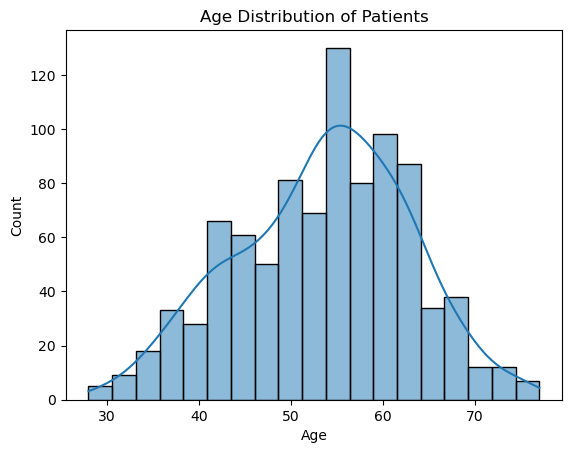

In [31]:
#histogram of age distribution 
sns.histplot(heart["Age"], kde=True)
plt.title("Age Distribution of Patients")



Text(0.5, 1.0, 'Cholesterol vs Heart Disease')

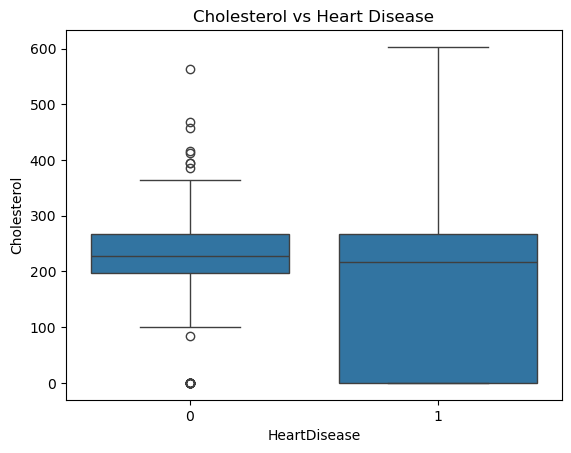

In [32]:
sns.boxplot(x="HeartDisease", y="Cholesterol", data=heart)
plt.title("Cholesterol vs Heart Disease")

Text(0.5, 1.0, ' maximum heart rate achieved vs HeartDisease ')

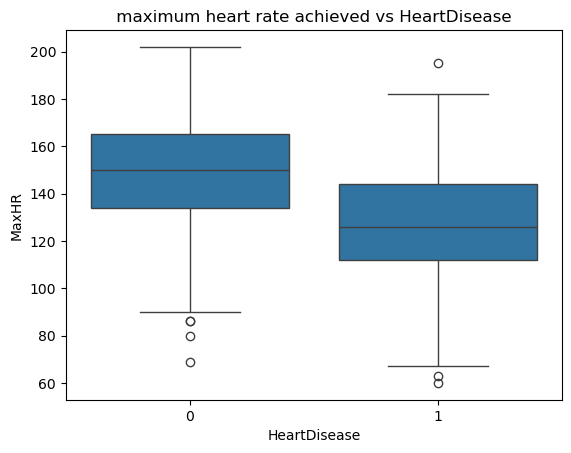

In [33]:
sns.boxplot(x="HeartDisease", y="MaxHR", data=heart)
plt.title(" maximum heart rate achieved vs HeartDisease ")

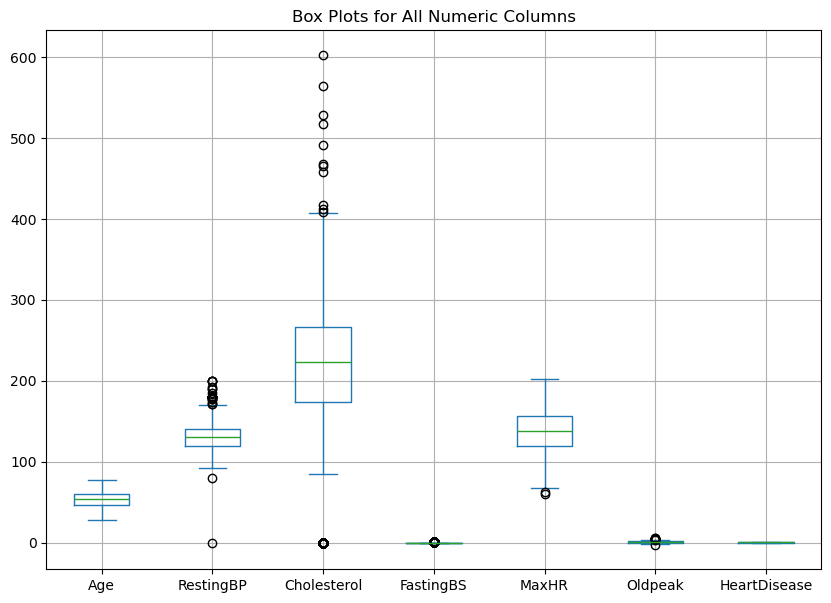

In [34]:
# Box plots for all numeric columns together
# This is helpful to compare ranges and detect outliers across multiple variables.
heart.plot(kind='box', grid=True, figsize=(10, 7), title="Box Plots for All Numeric Columns")
plt.show()

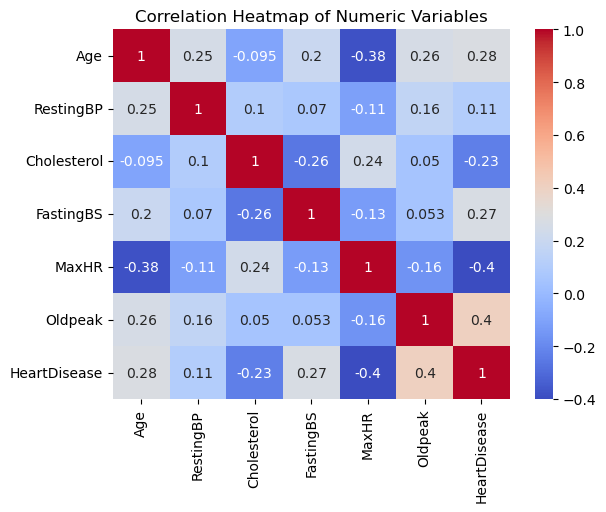

In [35]:
# ---------------------------------------------
#  Heatmap of correlations
# ---------------------------------------------

# Compute correlation between numeric variables
corr = heart.corr(numeric_only=True)

# Display a heatmap for visual inspection of correlations
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


In [36]:
heart = heart[heart['Cholesterol'] != 0]

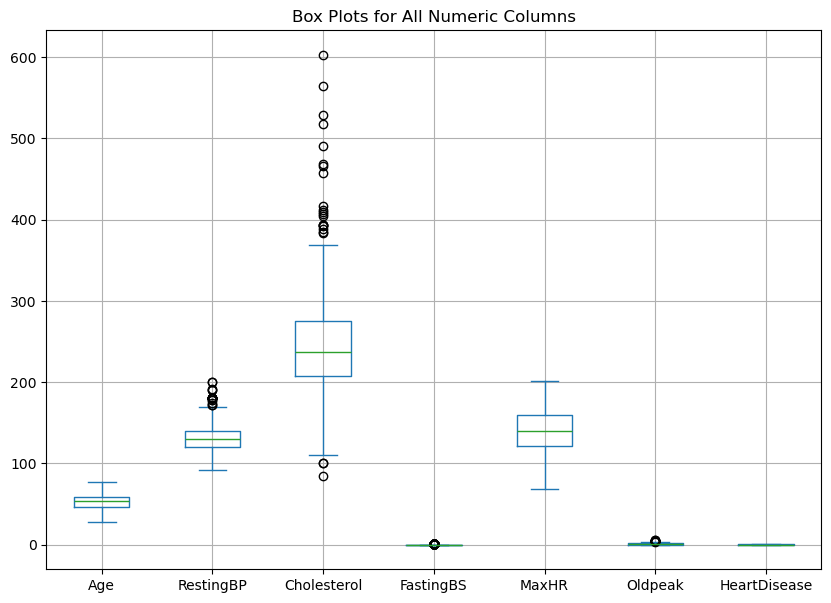

In [37]:
# Box plots for all numeric columns together after removing 0-cholesterol values.
# This is helpful to compare ranges and detect outliers across multiple variables.
heart.plot(kind='box', grid=True, figsize=(10, 7), title="Box Plots for All Numeric Columns")
plt.show()

In [38]:
x= heart.drop(columns=['HeartDisease']).select_dtypes(include=['int64','float64'])
y= heart['HeartDisease']
# Convert labels to integers for metrics
y_encoded = LabelEncoder().fit_transform(y)
#SCALE THE FEATURES FOR CLUSTERING
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
 # Print samples
print("Features (X):\n", x[:5])
print("Labels (Y):\n", y[:5])
print("Encoded labels:\n", y_encoded[:5])

Features (X):
    Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak
0   40        140          289          0    172      0.0
1   49        160          180          0    156      1.0
2   37        130          283          0     98      0.0
3   48        138          214          0    108      1.5
4   54        150          195          0    122      0.0
Labels (Y):
 0    0
1    1
2    0
3    1
4    0
Name: HeartDisease, dtype: int64
Encoded labels:
 [0 1 0 1 0]


In [39]:
#ensure that all numeric features are standarised for fair distance calculations
x_numeric = x.astype(np.float64)
x_scaled = scale(x_numeric)
print("Before scaling: mean=", x_numeric.mean(axis=0)," std=", x_numeric.std(axis=0))
x_scaled = scale(x_numeric)
print("After scaling: mean=", x_numeric.mean(axis=0)," std=", x_scaled.std(axis=0))

Before scaling: mean= Age             52.882038
RestingBP      133.022788
Cholesterol    244.635389
FastingBS        0.167560
MaxHR          140.226542
Oldpeak          0.901609
dtype: float64  std= Age             9.505888
RestingBP      17.282750
Cholesterol    59.153524
FastingBS       0.373726
MaxHR          24.524107
Oldpeak         1.072861
dtype: float64
After scaling: mean= Age             52.882038
RestingBP      133.022788
Cholesterol    244.635389
FastingBS        0.167560
MaxHR          140.226542
Oldpeak          0.901609
dtype: float64  std= [1. 1. 1. 1. 1. 1.]


In [40]:
# ----Silhouette score for different number of clusters---
print("K-Means clustering for k=2 to 7:")
for k in range(2,8):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(x_scaled)
    print(f"\nk = {k}")
    print("Silhouette score =", metrics.silhouette_score(x_scaled, kmeans.labels_))
    print("Completeness score=", metrics.completeness_score(y_encoded, kmeans.labels_))
    print("Homogeneity score=", metrics.homogeneity_score(y_encoded, kmeans.labels_))
    

K-Means clustering for k=2 to 7:

k = 2
Silhouette score = 0.20848610392392886
Completeness score= 0.16243945444931396
Homogeneity score= 0.16227482515182448

k = 3
Silhouette score = 0.2315631966118507
Completeness score= 0.10508335106244833
Homogeneity score= 0.15558235825847944

k = 4
Silhouette score = 0.18512581424527808
Completeness score= 0.07797310421591949
Homogeneity score= 0.15265780733020912

k = 5
Silhouette score = 0.18371764400336713
Completeness score= 0.08542469491522928
Homogeneity score= 0.194831771916355

k = 6
Silhouette score = 0.18641633049154835
Completeness score= 0.07606695932498957
Homogeneity score= 0.19167435227749122

k = 7
Silhouette score = 0.18445067371875581
Completeness score= 0.08217202329703514
Homogeneity score= 0.22025294722033528


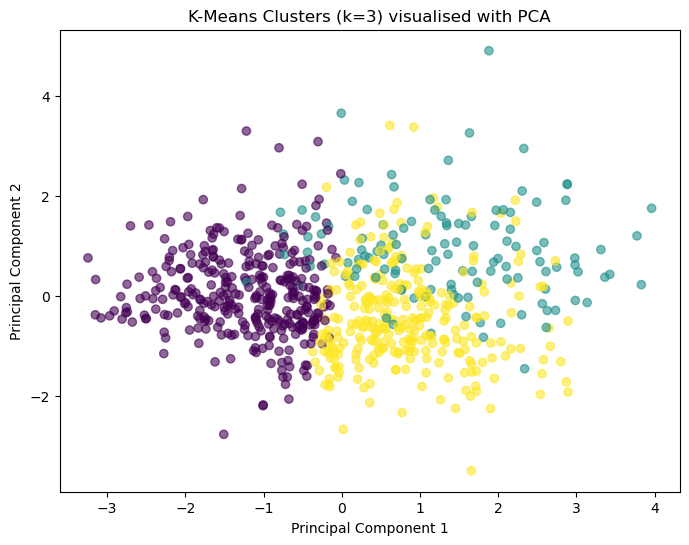

In [41]:
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Apply PCA to reduce to 2 dimensions for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

# Fit K-Means (we use k=3 because it gave the best silhouette score)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(x_scaled)

# Plot PCA-reduced data colored by cluster
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.title("K-Means Clusters (k=3) visualised with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [54]:
#------supervised analysis--------
from sklearn import model_selection
#encode binary categorical features
heart['Sex']= heart['Sex'].map({'M':0,'F':1 })
heart['ExerciseAngina']= heart['ExerciseAngina'].map({'Y':1,'N':0 })

#heart= pd.get_dummies(heart, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first= True)
X= heart.drop(columns=['HeartDisease'])
y= heart['HeartDisease']

In [55]:
heart.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [56]:
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape) 


Training set shape: (642, 11)
Test set shape: (276, 11)


In [60]:
#Standarise the features
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'ASY'

In [58]:
print("Any NaN values?\n", X_train.isnull().sum())
print("\nColumns with one unique value:\n", X_train.nunique())

Any NaN values?
 Age                 0
Sex               642
ChestPainType       0
RestingBP           0
Cholesterol         0
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina    642
Oldpeak             0
ST_Slope            0
dtype: int64

Columns with one unique value:
 Age                47
Sex                 0
ChestPainType       4
RestingBP          55
Cholesterol       197
FastingBS           2
RestingECG          3
MaxHR             110
ExerciseAngina      0
Oldpeak            49
ST_Slope            3
dtype: int64


In [59]:
print(heart['Sex'].unique())
print(heart['ExerciseAngina'].unique())

[nan]
[nan]


In [47]:
# Load the original dataset again 
heart = pd.read_csv("heart.csv") 

# Check unique values again
print(heart['Sex'].unique())
print(heart['ExerciseAngina'].unique())

['M' 'F']
['N' 'Y']


In [48]:
heart['Sex'] = heart['Sex'].astype(str).str.strip().str.upper().map({'M': 0, 'F': 1})
heart['ExerciseAngina'] = heart['ExerciseAngina'].astype(str).str.strip().str.upper().map({'Y': 1, 'N': 0})

In [49]:
print(heart['Sex'].unique())
print(heart['ExerciseAngina'].unique())

[0 1]
[0 1]


In [50]:
# One-hot encode the other categorical features again
#heart = pd.get_dummies(heart, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)

# Split and scale again
X = heart.drop(columns=['HeartDisease'])
y = heart['HeartDisease']
#test data 30%, trained data 70%
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'ASY'

In [51]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Y_train distribution:\n", Y_train.value_counts())

NameError: name 'X_train_scaled' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

#train model
log_reg = LogisticRegression(max_iter = 1000, random_state=42)
#fit logistic regression on the training data
log_reg.fit(X_train_scaled, Y_train)
#predictions
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(Y_test, y_prob))

In [52]:
#display ROC curve
fpr, tpr, _ = roc_curve(Y_test, y_prob)
plt.plot(fpr, tpr, label= 'Logistic Regression', color= 'purple')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

NameError: name 'roc_curve' is not defined

In [61]:
import pandas as pd, numpy as np
coefs = pd.Series(log_reg.coef_[0], index=X.columns)
odds = np.exp(coefs)
pd.DataFrame({'Coefficient': coefs, 'Odds Ratio': odds}).sort_values('Odds Ratio', ascending=False)

NameError: name 'log_reg' is not defined